# 인공지능수학 4주차 — 교실 실습

**시간:** 75분 | **구성:** 손문제 (35분) + 버그 잡기 (20분) + 코딩 실습 (20분)

**이름:** ___________________ &emsp; **학번:** ___________________

---
## 💡 오늘 영상에서 배운 것

- 다항함수 미분 규칙, chain rule: "바깥 미분 × 안 미분"
- MSE gradient: $\frac{\partial\mathcal{L}}{\partial w} = \frac{2}{m}\sum(\hat{y}_i-y_i)x_i$
- 경사하강법: $w \leftarrow w - \alpha\frac{\partial\mathcal{L}}{\partial w}$
- 학습률: 너무 작으면 느리고, 너무 크면 진동·발산

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

---
# Part A. 손으로 푸는 문제 (35분)

## 문제 1. 미분과 최솟값 (10분)

**(1)** 다음 함수를 미분하고 최솟값을 구하세요.

$$f(x) = 2x^2 - 8x + 9$$

$f'(x) = $ &emsp;&emsp; $x^* = $ &emsp;&emsp; $f(x^*) = $

<br>

**(2)** Chain rule을 써서 미분하세요.

$$g(w) = (3w - 2)^2$$

$g'(w) = $ &emsp; (힌트: 바깥 $u^2$ 미분 × 안 $3w-2$ 미분)

<br>

**(3)** MSE gradient의 핵심: 다음을 $w$에 대해 미분하세요.

$$h(w) = (wx_i - y_i)^2 \quad (x_i=2,\; y_i=3 \text{ 은 상수})$$

$h'(w) = $

<br><br>

## 문제 2. MSE gradient 손계산 (15분)

데이터: $(x_1,y_1)=(1,2),\;(x_2,y_2)=(2,4),\;(x_3,y_3)=(3,6)$ &emsp; 초기값: $w=0,\;b=0$

**(1)** 예측값 $\hat{y}_i = wx_i + b$ 와 잔차 $e_i = \hat{y}_i - y_i$ 를 구하세요.

| $i$ | $x_i$ | $y_i$ | $\hat{y}_i$ | $e_i$ |
|:---:|:---:|:---:|:---:|:---:|
| 1 | 1 | 2 | | |
| 2 | 2 | 4 | | |
| 3 | 3 | 6 | | |

<br>

**(2)** Gradient를 계산하세요.

$$\frac{\partial\mathcal{L}}{\partial w} = \frac{2}{3}\sum_{i=1}^3 e_i x_i = \quad\quad\quad\quad$$

$$\frac{\partial\mathcal{L}}{\partial b} = \frac{2}{3}\sum_{i=1}^3 e_i = \quad\quad\quad\quad$$

<br>

**(3)** 학습률 $\alpha=0.1$ 로 한 스텝 업데이트하세요.

$$w_1 = w_0 - 0.1 \times \frac{\partial\mathcal{L}}{\partial w} = \quad\quad$$

$$b_1 = b_0 - 0.1 \times \frac{\partial\mathcal{L}}{\partial b} = \quad\quad$$

<br>

## 문제 3. 학습률 분석 (10분)

$\mathcal{L}(w) = (w-3)^2$ 에 경사하강법을 적용합니다. ($b$ 없음)

**(1)** $\frac{\partial\mathcal{L}}{\partial w}$를 구하세요. &emsp;&emsp; $\frac{\partial\mathcal{L}}{\partial w} = $

<br>

**(2)** $w_0=0$, $\alpha=0.5$ 로 3번 업데이트한 표를 채우세요.

| step | $w$ | &nbsp;&nbsp;&nbsp; $\frac{\partial\mathcal{L}}{\partial w}$ &nbsp;&nbsp;&nbsp;| $\mathcal{L}(w)$  |
|:---:|:---:|:---:|:---:|
| 0 | 0 | | |
| 1 | | | |
| 2 | | | |
| 3 | | | |

<br>

**(3)** $\alpha=1.1$ 이면 어떻게 될지 예측하고 이유를 쓰세요.

<br><br>

---
# Part B. 🐛 팀 버그 잡기 (20분)

### 버그 1. 업데이트 방향 오류 — 에러 없음, 결과 틀림

In [3]:
# 🐛 Bug 1
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 4.0, 6.0])
w, b, lr = 0.0, 0.0, 0.1
losses = []
for _ in range(30):
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum((y_hat - y) * x)
    db = (2/len(x)) * np.sum(y_hat - y)
    w = w + lr*dw   # ← bug
    b = b + lr*db
    losses.append(np.mean((w*x+b-y)**2))
print(f"w={w:.4f}, b={b:.4f}")
print(f"Loss trend: {[round(l,2) for l in losses[:5]]}")

w=-8878023572.0779, b=-3905457806.1642
Loss trend: [np.float64(82.79), np.float64(368.04), np.float64(1637.18), np.float64(7283.7), np.float64(32405.73)]


In [4]:
# ✅ Fix Bug 1
w, b = 0.0, 0.0
for _ in range(30):
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum((y_hat - y) * x)
    db = (2/len(x)) * np.sum(y_hat - y)
    w = w - lr*dw
    b = w - lr*db
print(f"Fixed: w={w:.4f}, b={b:.4f}")   # w≈2.0, b≈0.0

Fixed: w=1.4115, b=1.3721


### 버그 2. 손실 기록 타이밍

In [5]:
# 🐛 Bug 2 — loss recorded after update
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 4.0, 6.0])
w, b, lr = 0.0, 0.0, 0.3
losses = []
for _ in range(20):
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum((y_hat-y)*x)
    db = (2/len(x)) * np.sum(y_hat-y)
    w -= lr*dw; b -= lr*db
    losses.append(np.mean((w*x+b-y)**2))   # ← after update

initial_mse = np.mean((0*x+0-y)**2)
print(f"losses[0] = {losses[0]:.4f}")
print(f"초기 MSE (w=0,b=0) = {initial_mse:.4f}")
print("→ losses[0]이 초기 상태가 아님")

losses[0] = 100.8000
초기 MSE (w=0,b=0) = 18.6667
→ losses[0]이 초기 상태가 아님


In [6]:
# ✅ Fix Bug 2
w, b = 0.0, 0.0
losses_fixed = []
for _ in range(20):
    losses_fixed.append(np.mean((w*x+b-y)**2))   # record BEFORE update
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum((y_hat-y)*x)
    db = (2/len(x)) * np.sum(y_hat-y)
    w -= lr*dw; b -= lr*db
print(f"losses_fixed[0] = {losses_fixed[0]:.4f}")
print(f"초기 MSE         = {initial_mse:.4f}   ← 일치해야 함")

losses_fixed[0] = 18.6667
초기 MSE         = 18.6667   ← 일치해야 함


### 버그 3. Gradient 공식 오류

In [9]:
# 🐛 Bug 3 — missing x_i in dw gradient
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 4.0, 6.0])
w, b, lr = 0.0, 0.0, 0.1
for _ in range(100):
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum(y_hat - y)      # ← x 빠짐
    db = (2/len(x)) * np.sum(y_hat - y)
    w -= lr*dw; b -= lr*db
print(f"w={w:.4f}, b={b:.4f}")   # w≈2.0이어야 함

w=1.3333, b=1.3333


In [11]:
# ✅ Fix Bug 3
w, b = 0.0, 0.0
for _ in range(50):
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum((y_hat - y) * x)  # 올바른 gradient
    db = (2/len(x)) * np.sum(y_hat - y)
    w -= lr*dw; b -= lr*db
print(f"Fixed: w={w:.4f}, b={b:.4f}")   # w≈2.0, b≈0.0

Fixed: w=1.9039, b=0.2184


---
# Part C. 코딩 실습 (20분)

## 실습 1. 손계산 검증 (7분)

In [12]:
# Lab 1: verify Problem 1 and 2
# (1) f(x) = 2x^2 - 8x + 9
f  = lambda x: 2*x**2 - 8*x + 9
df = lambda x: 4*x-8   # f'(x)
x_star = 2
print(f"(1) x*={x_star}, f(x*)={f(x_star)}")

# (2) Problem 2: one step of GD
x_d = np.array([1.0, 2.0, 3.0])
y_d = np.array([2.0, 4.0, 6.0])
w0, b0 = 0.0, 0.0
y_hat = w0*x_d + b0
dw = (2/3) * np.sum((y_hat - y_d) * x_d)
db = (2/3) * np.sum(y_hat - y_d)
w1 = w0 - 0.1*dw
b1 = b0 - 0.1*db
print(f"(2) dw={dw:.4f}, db={db:.4f}")
print(f"    w1={w1:.4f}, b1={b1:.4f}")

(1) x*=2, f(x*)=1
(2) dw=-18.6667, db=-8.0000
    w1=1.8667, b1=0.8000


## 실습 2. 경사하강법 처음부터 구현 (13분)

w=1.4059 (true 3.0), b=1.3861 (true 1.0)


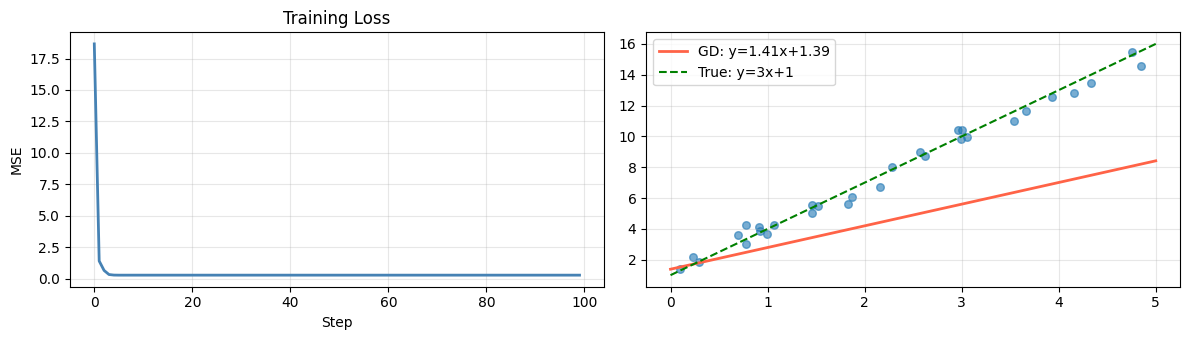

In [13]:
# Lab 2: implement gradient descent from scratch
np.random.seed(42)
m = 30
x_train = np.random.uniform(0, 5, m)
y_train = 3*x_train + 1 + np.random.randn(m)*0.5

w, b, lr = 0.0, 0.0, 0.05
losses = []

for _ in range(100):
    losses.append(np.mean((w*x+b-y)**2))            # MSE before update
    y_hat = w*x+b
    dw    = (2/len(x)) * np.sum((y_hat-y)*x)
    db    = (2/len(x)) * np.sum((y_hat-y))
    w     = w - lr * dw
    b     = w - lr * db

print(f"w={w:.4f} (true 3.0), b={b:.4f} (true 1.0)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(losses, color='steelblue', lw=2)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

x_line = np.linspace(0, 5, 100)
axes[1].scatter(x_train, y_train, alpha=0.6, s=30)
axes[1].plot(x_line, w*x_line+b, color='tomato', lw=2,
             label=f'GD: y={w:.2f}x+{b:.2f}')
axes[1].plot(x_line, 3*x_line+1, 'g--', lw=1.5, label='True: y=3x+1')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📋 체크리스트

- [ ] Chain rule로 $(wx-y)^2$을 $w$에 대해 미분할 수 있다
- [ ] MSE gradient 손계산을 할 수 있다
- [ ] `w = w - lr * dw` 에서 `-` 부호의 이유를 설명할 수 있다
- [ ] 손실 기록은 업데이트 전에 해야 하는 이유를 안다
- [ ] gradient 공식에서 `* x` 가 빠지면 왜 틀리는지 설명할 수 있다

---
## 🏠 과제

손문제 Part A 전체를 풀어서 **사진 또는 PDF로 LMS에 제출**하세요.